# Multivariate Change Point Detection Regime Segmentation
Here we implement a multivariate change point detection approach. Unlike HMMs which assume hidden states that we transition between, change point detection looks for structural breaks in the statistical properties of the time series.

In [21]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ruptures as rpt
from sklearn.preprocessing import StandardScaler
from dotenv import load_dotenv
from fredapi import Fred
import warnings
warnings.filterwarnings('ignore')

data_path = r'../../../data/master_data.csv'
df = pd.read_csv(data_path)

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

price_col = 'GSPC'
ret_col = 'Return'

print(f"Data loaded. Shape: {df.shape}")
df.head()

Data loaded. Shape: (6164, 27)


,Date,GSPC,VIX,SPY Volume,Gold,Oil,GDP,Core_Inflation,Unemployment,M2,...,MACD_Signal,MACD_Hist,GDP_YoY,Core_Inflation_YoY,M2_YoY,Peak,Drawdown,VIX_Change,VIX_Change_5d,Regime
0,2001-08-30,1129.030029,25.410000,17692600,275.399994,26.549999,14214.516,76.553,4.9,5243.8,...,-11.129843,-2.983369,0.004892,0.020421,0.088038,1520.77002,-0.257593,2.379999,3.180000,NaN
1,2001-08-31,1133.579956,24.920000,15985400,274.399994,27.200001,14214.516,76.553,4.9,5243.8,...,-12.009273,-3.517721,0.004892,0.020421,0.088038,1520.77002,-0.254601,-0.490000,5.210001,NaN
2,2001-09-04,1132.939941,25.850000,24473400,271.600006,26.930000,14214.516,76.118,5.0,5355.1,...,-12.909172,-3.599596,0.004892,0.012167,0.102962,1520.77002,-0.255022,0.930000,5.290001,NaN
3,2001-09-05,1131.739990,26.350000,21477100,272.000000,26.950001,14214.516,76.118,5.0,5355.1,...,-13.764448,-3.421104,0.004892,0.012167,0.102962,1520.77002,-0.255811,0.500000,4.350000,NaN
4,2001-09-06,1106.400024,28.610001,21653000,273.000000,27.580000,14214.516,76.118,5.0,5355.1,...,-14.919833,-4.621539,0.004892,0.012167,0.102962,1520.77002,-0.272474,2.260000,5.580000,NaN


## Fetch Consumer Sentiment from FRED API
Mirrors the GMM notebook's feature engineering: fetch the University of Michigan Consumer Sentiment Index (UMCSENT), then derive month-over-month change and a rolling 12-month z-score.

In [22]:
load_dotenv()
fred = Fred(api_key=os.getenv('FRED_API_KEY', ''))

sentiment = fred.get_series('UMCSENT').to_frame('Consumer_Sentiment')
sentiment.index = pd.to_datetime(sentiment.index)
sentiment = sentiment.resample('D').ffill()

df = df.merge(sentiment, left_on='Date', right_index=True, how='left')
df['Consumer_Sentiment'] = df['Consumer_Sentiment'].ffill().bfill()

# Month-over-month change (21 trading days ≈ 1 calendar month)
df['Consumer_Sentiment_MoM'] = df['Consumer_Sentiment'].diff(21)

# Rolling 12-month z-score (252 trading days, min_periods=63)
rolling_mean = df['Consumer_Sentiment'].rolling(252, min_periods=63).mean()
rolling_std  = df['Consumer_Sentiment'].rolling(252, min_periods=63).std()
df['Consumer_Sentiment_ZScore'] = (df['Consumer_Sentiment'] - rolling_mean) / rolling_std

print(f"Consumer Sentiment features added. Shape: {df.shape}")
print(f"Consumer_Sentiment NaN: {df['Consumer_Sentiment'].isna().sum()}")
print(f"Consumer_Sentiment_ZScore NaN: {df['Consumer_Sentiment_ZScore'].isna().sum()}")

Consumer Sentiment features added. Shape: (6164, 30)
Consumer_Sentiment NaN: 0
Consumer_Sentiment_ZScore NaN: 62


In [23]:
candidate_features = [
    'Return',
    'VIX', 'Drawdown',
    'RSI_14', 'MACD_Hist',
    'Consumer_Sentiment_ZScore',
    'Gold', 'Oil'
]

print(f"Candidate features ({len(candidate_features)}): {candidate_features}")

# Build working dataframe
df_work = df[['Date', price_col, ret_col] + [c for c in candidate_features if c not in [ret_col]]].copy()

print("\nMissing values BEFORE cleaning:")
print(df_work[candidate_features].isnull().sum())

df_work[candidate_features] = df_work[candidate_features].ffill(limit=5)
df_work[candidate_features] = df_work[candidate_features].interpolate(method='linear')

rows_before = len(df_work)
df_work = df_work.dropna(subset=candidate_features).reset_index(drop=True)
rows_after = len(df_work)

print(f"\nMissing values AFTER cleaning:")
print(df_work[candidate_features].isnull().sum())
print(f"\nRows dropped: {rows_before - rows_after} (from {rows_before} to {rows_after})")

Candidate features (8): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Gold', 'Oil']

Missing values BEFORE cleaning:
Return                        0
VIX                           0
Drawdown                      0
RSI_14                        0
MACD_Hist                     0
Consumer_Sentiment_ZScore    62
Gold                          0
Oil                           0
dtype: int64

Missing values AFTER cleaning:
Return                       0
VIX                          0
Drawdown                     0
RSI_14                       0
MACD_Hist                    0
Consumer_Sentiment_ZScore    0
Gold                         0
Oil                          0
dtype: int64

Rows dropped: 62 (from 6164 to 6102)


## Collinearity Analysis
Check for highly correlated features and remove redundant ones (threshold: |r| > 0.8), matching the GMM notebook's feature selection approach.

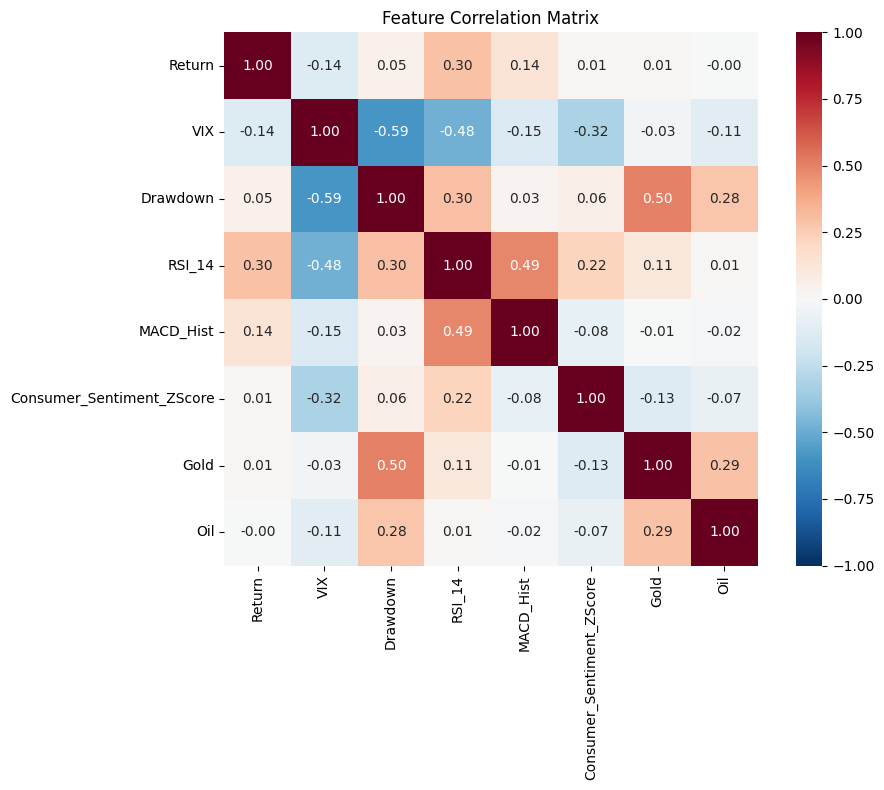

In [24]:
corr_matrix = df_work[candidate_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [25]:
collinearity_threshold = 0.8

upper_tri = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1))
high_corr_pairs = []
for col in upper_tri.columns:
    for idx in upper_tri.index:
        val = upper_tri.loc[idx, col]
        if pd.notna(val) and abs(val) > collinearity_threshold:
            high_corr_pairs.append((idx, col, round(val, 3)))

if high_corr_pairs:
    print(f"Highly correlated pairs (|r| > {collinearity_threshold}):")
    for f1, f2, r in high_corr_pairs:
        print(f"  {f1} <-> {f2}: r = {r}")
else:
    print("No highly correlated pairs found.")

features_to_drop = set()
for f1, f2, r in high_corr_pairs:
    if f1 not in features_to_drop and f2 not in features_to_drop:
        count_f1 = sum(1 for a, b, _ in high_corr_pairs if a == f1 or b == f1)
        count_f2 = sum(1 for a, b, _ in high_corr_pairs if a == f2 or b == f2)
        drop = f1 if count_f1 >= count_f2 else f2
        features_to_drop.add(drop)

selected_features = [f for f in candidate_features if f not in features_to_drop]

print(f"\nFeatures removed due to collinearity: {sorted(features_to_drop)}")
print(f"Selected features ({len(selected_features)}): {selected_features}")

No highly correlated pairs found.

Features removed due to collinearity: []
Selected features (8): ['Return', 'VIX', 'Drawdown', 'RSI_14', 'MACD_Hist', 'Consumer_Sentiment_ZScore', 'Gold', 'Oil']


## Standardise Selected Features

In [26]:
scaler = StandardScaler()
X_raw = df_work[selected_features].values
X = scaler.fit_transform(X_raw)

print(f"Feature matrix shape: {X.shape}")
print(f"Post-standardisation means:  {X.mean(axis=0).round(6)}")
print(f"Post-standardisation stds:   {X.std(axis=0).round(6)}")

Feature matrix shape: (6102, 8)
Post-standardisation means:  [ 0.  0. -0.  0. -0.  0.  0.  0.]
Post-standardisation stds:   [1. 1. 1. 1. 1. 1. 1. 1.]


Apply Ruptures (PELT) for CPD

In [27]:
print("Running Pelt search algorithm...")
model = "rbf"
algo = rpt.Pelt(model=model).fit(X)

# Higher penalty = fewer change points.
penalty = 5
result = algo.predict(pen=penalty)

print(f"Found {len(result) - 1} change points.")
print(f"Change point indices: {result[:-1]}")

Running Pelt search algorithm...
Found 102 change points.
Change point indices: [125, 160, 340, 520, 540, 685, 825, 875, 920, 985, 1115, 1170, 1215, 1315, 1330, 1420, 1490, 1590, 1635, 1665, 1715, 1765, 1845, 1915, 1965, 2075, 2115, 2160, 2265, 2325, 2430, 2480, 2530, 2605, 2650, 2730, 2765, 2870, 2940, 2960, 3020, 3225, 3245, 3275, 3315, 3450, 3480, 3510, 3575, 3625, 3670, 3715, 3760, 3840, 3985, 4025, 4070, 4115, 4240, 4300, 4325, 4385, 4405, 4445, 4465, 4510, 4585, 4610, 4635, 4720, 4740, 4775, 4840, 4945, 4975, 5000, 5020, 5065, 5075, 5105, 5120, 5150, 5190, 5215, 5245, 5285, 5310, 5335, 5360, 5430, 5450, 5515, 5535, 5620, 5640, 5695, 5710, 5845, 5860, 5885, 5905, 6000]


Map segments to Regimes (Bull/Bear)

In [28]:
df_work['regime'] = 'unknown'
df_work['segment'] = 0

start_idx = 0
for i, end_idx in enumerate(result):
    segment_data = df_work.iloc[start_idx:end_idx]
    
    # mean return for the segment
    mean_ret = segment_data[ret_col].mean()
    
    # simple heuristic: positive mean return -> bull, negative -> bear
    regime = 'bull' if mean_ret > 0 else 'bear'
    
    df_work.loc[start_idx:end_idx-1, 'regime'] = regime
    df_work.loc[start_idx:end_idx-1, 'segment'] = i
    
    start_idx = end_idx

if 'Regime' in df.columns:
    df = df.drop(columns=['Regime'])

df = df.merge(df_work[['Date', 'regime', 'segment']], on='Date', how='left')
first_regime = df_work['regime'].iloc[0]
df['regime'] = df['regime'].fillna(first_regime)

print("\nRegime Counts:")
print(df['regime'].value_counts())
print("\nRegime Proportions:")
print(df['regime'].value_counts(normalize=True).round(3))


Regime Counts:
regime
bull    4257
bear    1907
Name: count, dtype: int64

Regime Proportions:
regime
bull    0.691
bear    0.309
Name: proportion, dtype: float64


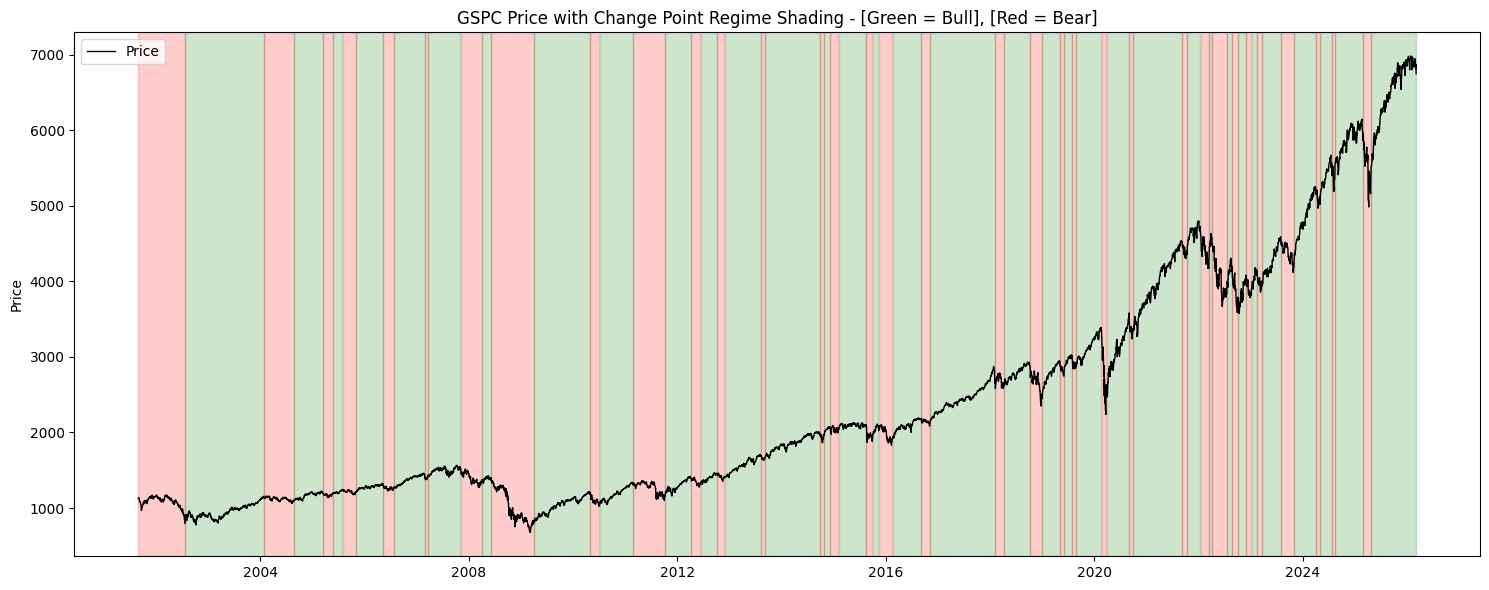

In [29]:
fig, ax1 = plt.subplots(1, 1, figsize=(15, 6))
ax1.plot(df['Date'], df[price_col], color='black', linewidth=1, label='Price')
ax1.set_title(f'{price_col} Price with Change Point Regime Shading - [Green = Bull], [Red = Bear]')
ax1.set_ylabel('Price')
ax1.legend(loc='upper left')

# Add shading
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).cumsum()
for _, group in df.groupby('regime_change'):
    start_date = group['Date'].iloc[0]
    end_date = group['Date'].iloc[-1]
    regime = group['regime'].iloc[0]
    color = 'green' if regime == 'bull' else 'red'
    ax1.axvspan(start_date, end_date, color=color, alpha=0.2)

plt.tight_layout()
plt.show()
df = df.drop(columns=['regime_change'])

In [30]:
missing_regimes = df['regime'].isna().sum()
assert missing_regimes == 0, f"Error: Found {missing_regimes} missing values in 'regime' column!"
print("Validation passed: No missing values in 'regime' column.")

output_csv = r'../../../data/multivariate_changepoint_labeled_dataset.csv'
df.to_csv(output_csv, index=False)
print(f"Dataset saved to {output_csv}")

Validation passed: No missing values in 'regime' column.
Dataset saved to ../../../data/multivariate_changepoint_labeled_dataset.csv
